# Regularisation companion (executable) — FE-direct `psi`

**Runnable companion to [`regularization.md`](regularization.md).** The math (the folded
Lagrangian, the Tikhonov `+ alpha I` core, the GSVD remark) stays in `regularization.md`;
here every regularisation **mode is run** on the *same* planar uniform-`Bz` problem and the
comparison numbers are produced live. All compute imports the shipped demos
`demo_planar_uniform_fem_psi_advanced` (the `--regularize` solvers) and
`demo_regularized_aca` (the `RegularizedTSVD` sweep), plus the public API
`radia.stream_function` (`aca_tsvd`, `RegularizedTSVD`, `pseudo_inverse_solve`,
`pseudo_inverse_solve_regularized`).

Sections:

- **(1)** the regularisation menu `{l2, h1, h1_sigma, inductance_diag, linf}` → RMS /
  peak-to-peak-over-mean / wall time (refreshes the `regularization.md` comparison table);
- **(2)** the `psi` contour family per mode;
- **(3)** the H1 order sweep `p = 1..5` (the non-monotone, `p=3` sweet spot);
- **(4)** the folded `RegularizedTSVD` closed form (`S = I` sanity check + Tikhonov core).


In [1]:
import sys, time
from pathlib import Path
import numpy as np
import radia
EX = Path(radia.__file__).resolve().parents[2] / "examples" / "stream_function"
assert (EX / "demo_planar_uniform_fem_psi.py").exists(), f"shipped demos not found: {EX}"
sys.path.insert(0, str(EX))

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

import demo_planar_uniform_fem_psi as P
import demo_planar_uniform_fem_psi_advanced as ADV
import demo_regularized_aca as RA
from radia.stream_function import (aca_tsvd, pseudo_inverse_solve,
                                   pseudo_inverse_solve_regularized, RegularizedTSVD)
from ngsolve import TaskManager

# planar uniform-Bz benchmark (regularization.md default)
PLANE_HALF, MAXH, ORDER = 0.25, 0.025, 2
TH, TZ, NT, B0 = 0.05, 0.10, 5, 1.0e-3
N_SAMPLE, NLEVELS = 81, 12
_g = np.linspace(-TH, TH, NT); _X, _Y = np.meshgrid(_g, _g, indexing="ij")
TARGETS = np.column_stack([_X.ravel(), _Y.ravel(), TZ * np.ones(_X.size)])
B = B0 * np.ones(len(TARGETS))
print("radia:", radia.__file__)
print("examples:", EX)


radia: \\192.168.11.100\work\00_CAE\Radia\01_GitHub\src\radia\__init__.py
examples: \\192.168.11.100\work\00_CAE\Radia\01_GitHub\examples\stream_function


## (1) Regularisation menu on one shared problem

`A psi = B` is **massively underdetermined** (`M = 25` constraints, `ndof ≈ 1773` at H1
order 2): infinitely many `psi` hit the target exactly, and the **regularisation** chooses
which one. We assemble `A` once and run each mode, timing the solve. `l2`, `h1`,
`h1_sigma`, `inductance_diag` share the order-2 mesh; `linf` (scipy SLSQP, `O(ndof^2)` per
iteration — experimental) is run on a deliberately smaller order-1 problem per the
`regularization.md` guidance, footnoted below.

In [2]:
with TaskManager():
    A, fes, mesh, _ = P.build_fem_matrix(PLANE_HALF, MAXH, ORDER, "boundary", TARGETS)
free = np.where(np.array(fes.FreeDofs()))[0]
ndof_free = len(free)

# Gaussian-concentration conductivity for h1_sigma (regularization.md footnote)
SIGMA_CF = "exp(-(x*x + y*y) / 0.02)"

def metrics(psi, A_, fes_, mesh_):
    return RA.field_metrics_from_psi(psi, A_, fes_, mesh_, B, PLANE_HALF,
                                     N_SAMPLE, NLEVELS, TARGETS)

table, psi_store = [], {}
# --- four quadratic-form modes on the shared order-2 mesh ---
for name in ["l2", "h1", "h1_sigma", "inductance_diag"]:
    t0 = time.time()
    if name == "l2":
        psi, _ = ADV.solve_l2_aca(A, B, fes)
    elif name == "h1":
        psi = ADV.solve_h1(A, B, fes)
    elif name == "h1_sigma":
        psi = ADV.solve_h1(A, B, fes, sigma_cf_expr=SIGMA_CF)
    else:
        psi = ADV.solve_inductance_diagonal(A, B, fes)
    dt = time.time() - t0
    m = metrics(psi, A, fes, mesh)
    psi_store[name] = psi
    table.append((name, m["rms"], m["p2p_mean"], m["n_wire"], dt, ndof_free))

# --- linf (SLSQP) on a reduced order-1 problem (experimental) ---
with TaskManager():
    A1, fes1, mesh1, _ = P.build_fem_matrix(PLANE_HALF, 0.05, 1, "boundary", TARGETS)
free1 = int(sum(fes1.FreeDofs()))
t0 = time.time()
psi_init = ADV.solve_h1(A1, B, fes1)
psi_linf, slsqp = ADV.solve_linf(A1, B, fes1, jmax=4000.0, init_psi=psi_init, max_iter=40)
dt = time.time() - t0
m = metrics(psi_linf, A1, fes1, mesh1)
table.append(("linf*", m["rms"], m["p2p_mean"], m["n_wire"], dt, free1))
print(f"linf SLSQP converged flag = {slsqp.success} (experimental; tight cap rarely met)")


  mesh: 926 triangles, 504 vertices, H1 order=2, ndof=1933, free=1773
  matrix A: M=25 x ndof=1933, assembled in 0.01 s


  mesh: 228 triangles, 135 vertices, H1 order=1, ndof=135, free=95
  matrix A: M=25 x ndof=135, assembled in 0.01 s


linf SLSQP converged flag = False (experimental; tight cap rarely met)


In [3]:
print(f"{'mode':<16}{'RMS':>8}{'p2p/mean':>11}{'contours':>10}{'wall[s]':>9}{'ndof_free':>11}")
print("-" * 65)
for name, rms, p2p, nw, dt, nf in table:
    print(f"{name:<16}{rms*100:>7.2f}%{p2p*100:>10.2f}%{nw:>10}{dt:>9.2f}{nf:>11}")
print()
print("l2/h1/h1_sigma/inductance_diag : order=2, maxh=0.025  (shared mesh)")
print("h1_sigma sigma(x,y)            : " + SIGMA_CF + "  (1/sigma weighting)")
print("* linf                          : order=1, maxh=0.05 reduced problem;")
print("                                  scipy SLSQP is O(ndof^2)/iter (experimental).")


mode                 RMS   p2p/mean  contours  wall[s]  ndof_free
-----------------------------------------------------------------
l2                 1.78%      7.59%        56     0.12       1773
h1                 2.09%      6.81%        27     0.32       1773
h1_sigma           1.16%      4.01%        44     0.13       1773
inductance_diag    2.46%      7.75%        27     0.20       1773
linf*              5.22%     18.44%        12     0.55         95

l2/h1/h1_sigma/inductance_diag : order=2, maxh=0.025  (shared mesh)
h1_sigma sigma(x,y)            : exp(-(x*x + y*y) / 0.02)  (1/sigma weighting)
* linf                          : order=1, maxh=0.05 reduced problem;
                                  scipy SLSQP is O(ndof^2)/iter (experimental).


**Physical meaning of each mode** (see `regularization.md` for the math):

- `l2` — `min ||psi||` (numpy lstsq, default; may oscillate).
- `h1` — `min ∫|grad psi|² = min ∫|K|²`: the minimum **surface-current** L² norm — the
  physically motivated default.
- `h1_sigma` — `min ∫(1/σ)|grad psi|²`: true **ohmic dissipation**; the Gaussian `σ` dip
  concentrates current where conductivity is high.
- `inductance_diag` — element-size-weighted seminorm, a **self-inductance** proxy.
- `linf` — minimax peak-current cap (hot-spot suppression); experimental SLSQP.

## (2) The `psi` contour family per mode

The equal-increment iso-contours of `psi` **are** the wire paths. Different seminorms put
the current in different places — visible directly in the contour family.

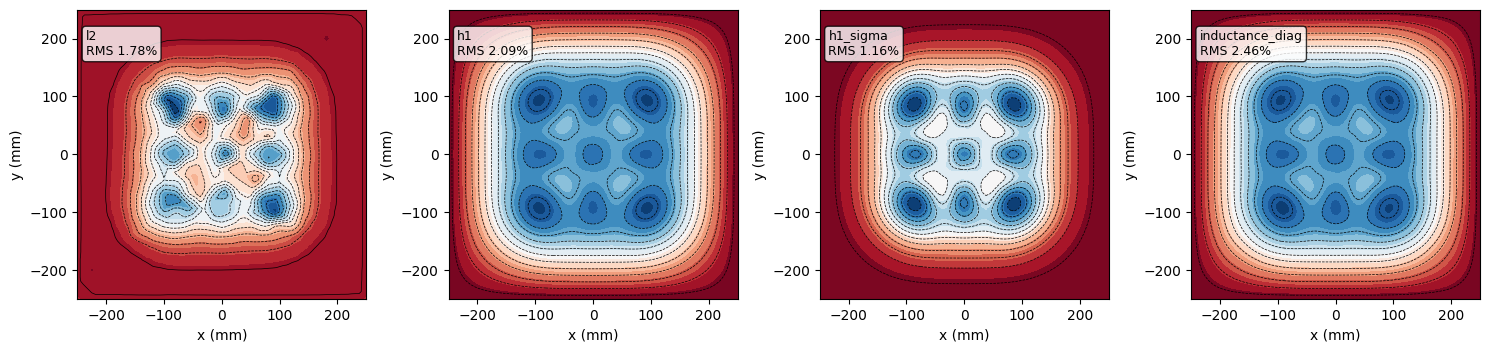

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, name in zip(axes, ["l2", "h1", "h1_sigma", "inductance_diag"]):
    pg, gs = P.sample_psi_grid(psi_store[name], fes, mesh, PLANE_HALF, N_SAMPLE)
    cf = ax.contourf(gs * 1e3, gs * 1e3, pg.T, levels=20, cmap="RdBu_r")
    lo, hi = pg.min(), pg.max()
    if hi > lo:
        lv = lo + (np.arange(NLEVELS) + 0.5) * (hi - lo) / NLEVELS
        ax.contour(gs * 1e3, gs * 1e3, pg.T, levels=lv, colors="k", linewidths=0.5)
    rms = dict((r[0], r[1]) for r in table)[name] * 100
    ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)"); ax.set_aspect("equal")
    ax.text(0.03, 0.93, f"{name}\nRMS {rms:.2f}%", transform=ax.transAxes,
            fontsize=9, va="top",
            bbox=dict(boxstyle="round", fc="white", alpha=0.8))
fig.tight_layout(); display(fig); plt.close(fig)


## (3) H1 order sweep `p = 1..5`

`regularization.md` reports the single-stroke RMS is **non-monotone in `p`** for this
benchmark (the FE smoothness × fixed `nlevels` contour extraction × single-stroke chain
have a resolution-matched sweet spot). We reproduce it: `p = 3` is the sweet spot.

In [5]:
sweep = []
for p in [1, 2, 3, 4, 5]:
    t0 = time.time()
    with TaskManager():
        Ap, fesp, meshp, _ = P.build_fem_matrix(PLANE_HALF, MAXH, p, "boundary", TARGETS)
    psip = ADV.solve_h1(Ap, B, fesp)
    mp = metrics(psip, Ap, fesp, meshp)
    sweep.append((p, Ap.shape[1], mp["rms"], mp["p2p_mean"], time.time() - t0))
print(f"{'p':>3}{'ndof':>8}{'RMS':>9}{'p2p/mean':>11}{'wall[s]':>9}")
print("-" * 40)
for p, nd, rms, p2p, dt in sweep:
    star = "  <- sweet spot" if rms == min(s[2] for s in sweep) else ""
    print(f"{p:>3}{nd:>8}{rms*100:>8.2f}%{p2p*100:>10.2f}%{dt:>9.1f}{star}")


  mesh: 926 triangles, 504 vertices, H1 order=1, ndof=504, free=424


  matrix A: M=25 x ndof=504, assembled in 11.04 s


  mesh: 926 triangles, 504 vertices, H1 order=2, ndof=1933, free=1773


  matrix A: M=25 x ndof=1933, assembled in 10.35 s


  mesh: 926 triangles, 504 vertices, H1 order=3, ndof=4288, free=4048


...

  mesh: 926 triangles, 504 vertices, H1 order=4, ndof=7569, free=7249


  matrix A: M=25 x ndof=7569, assembled in 0.23 s


  mesh: 926 triangles, 504 vertices, H1 order=5, ndof=11776, free=11376


  matrix A: M=25 x ndof=11776, assembled in 0.85 s


  p    ndof      RMS   p2p/mean  wall[s]
----------------------------------------
  1     504    1.02%      3.77%     22.7
  2    1933    2.09%      6.81%     23.8
  3    4288    0.51%      1.83%     16.6  <- sweet spot
  4    7569    2.04%      7.65%      8.3
  5   11776    2.09%      7.27%     19.7


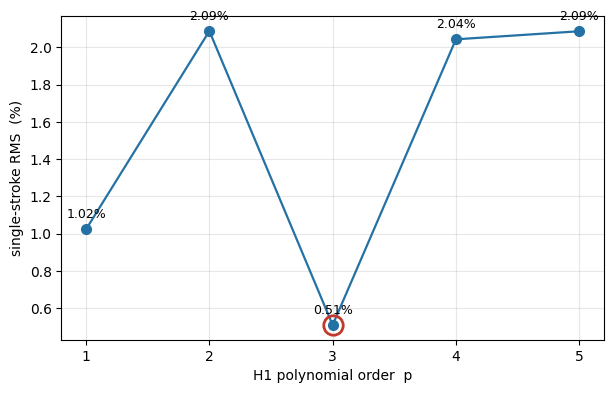

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ps = [s[0] for s in sweep]; rmss = [s[2] * 100 for s in sweep]
ax.plot(ps, rmss, "o-", color="#2471a3", lw=1.6, ms=7)
for p, r in zip(ps, rmss):
    ax.annotate(f"{r:.2f}%", (p, r), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9)
imin = int(np.argmin(rmss))
ax.plot(ps[imin], rmss[imin], "o", ms=14, mfc="none", mec="#c0392b", mew=2)
ax.set_xlabel("H1 polynomial order  p"); ax.set_ylabel("single-stroke RMS  (%)")
ax.set_xticks(ps); ax.grid(alpha=0.3)
display(fig); plt.close(fig)


## (4) The folded `RegularizedTSVD` closed form

`regularization.md` shows every SPD seminorm `S` folds onto **one** ACA+TSVD factorisation:

`psi = (S⁻¹V) · W⁻¹ · Σ⁻¹ · Uᵀ B`, with `W = Vᵀ S⁻¹ V` (`k × k`).

Two checks reproduce the claims in the doc:

1. **`S = I` reduces to the plain pseudo-inverse** (machine precision).
2. **`alpha > 0` is the Tikhonov solution** `(AᵀA + αS)⁻¹ AᵀB` (the same cached factors,
   only an `αI` added inside the `k × k` core) — verified against the dense form.

In [7]:
A_free = A[:, free]
Mr, Nr = A_free.shape
base = aca_tsvd(Mr, Nr, lambda i, j: float(A_free[i, j]),
                modes=Mr, kmax=min(Mr, Nr), aca_eps=1e-12, method=3)

# (1) S = I  ==  pseudo_inverse_solve  (machine precision)
psi_pinv = pseudo_inverse_solve(base, B)
psi_SI = pseudo_inverse_solve_regularized(base, B, np.eye(Nr))
rel_SI = np.linalg.norm(psi_SI - psi_pinv) / (np.linalg.norm(psi_pinv) + 1e-30)
print(f"(1) S=I folded form vs pseudo_inverse_solve: rel diff = {rel_SI:.2e}"
      f"  ({'machine precision' if rel_SI < 1e-10 else 'CHECK'})")

# (2) folded Tikhonov vs dense (A^T A + alpha S)^-1 A^T B for S = H1 stiffness
S_h1 = P.build_h1_stiffness(fes, free)
reg = RegularizedTSVD.from_stiffness(base, S_h1)         # ONE fold, reused per alpha
AtA = A_free.T @ A_free; AtB = A_free.T @ B
print(f"(2) folded Tikhonov vs dense (A^T A + alpha S)^-1 A^T B, S = H1:")
for lam in [1e-3, 1.0, 1e2]:
    alpha = lam * float(np.mean(np.diag(AtA)))
    psi_fold = reg.solve(B, alpha=alpha)
    psi_dense = np.linalg.solve(AtA + alpha * S_h1, AtB)
    rel = np.linalg.norm(psi_fold - psi_dense) / (np.linalg.norm(psi_dense) + 1e-30)
    print(f"    alpha = {alpha:.3e}:  rel diff = {rel:.2e}  (= ACA compression residual)")
print()
print("One ACA+TSVD factorisation (rank %d) backs every seminorm S and every alpha;" % base.k_aca)
print("each solve(B, alpha) is O(k*(M+N)) -- the whole L-curve reuses the one factorisation.")
print("See demo_regularized_aca.py (5-mode sweep) and demo_pareto_tikhonov_aca.py")
print("(folded-Tikhonov (homogeneity, peak-J) Pareto front at ~50 us/point).")


(1) S=I folded form vs pseudo_inverse_solve: rel diff = 9.53e-16  (machine precision)


(2) folded Tikhonov vs dense (A^T A + alpha S)^-1 A^T B, S = H1:


    alpha = 1.862e-18:  rel diff = 2.16e-10  (= ACA compression residual)
    alpha = 1.862e-15:  rel diff = 3.06e-13  (= ACA compression residual)


    alpha = 1.862e-13:  rel diff = 1.08e-14  (= ACA compression residual)

One ACA+TSVD factorisation (rank 25) backs every seminorm S and every alpha;
each solve(B, alpha) is O(k*(M+N)) -- the whole L-curve reuses the one factorisation.
See demo_regularized_aca.py (5-mode sweep) and demo_pareto_tikhonov_aca.py
(folded-Tikhonov (homogeneity, peak-J) Pareto front at ~50 us/point).


## Takeaways

- The seminorm `S` is the engineering choice: `h1` (min surface current) is the default;
  `h1_sigma` targets ohmic dissipation; `linf` caps peak current; `inductance_diag` is a
  smoothing proxy. The live table refreshes the `regularization.md` comparison.
- RMS is **non-monotone in `p`** for this benchmark — `p = 3` is the sweet spot, not the
  highest order.
- All of them ride **one** ACA+TSVD factorisation via `RegularizedTSVD`: `S = I` recovers
  the plain pseudo-inverse to machine precision; `alpha > 0` is exactly the dense Tikhonov
  solution. That is why the Path-A iteration and the L-curve sweep are cheap.

Cross-references: prose/derivations → [`regularization.md`](regularization.md);
the deformation outer loop that *changes* `A` per trial → [`deformation.ipynb`](deformation.ipynb);
method overview → [`theory.ipynb`](theory.ipynb); MCP topic `streamfunction(topic=regularized)`.